# Probabilities Is Not All You Need?
## Chasing Determinism In Training, Logits And Real-World Predictions Across Classical ML, Supervised NLP, And Low-Rank Adapted Foundation Models

*Simon Reichel*

---
## TOC
1. Environment info
2. Determinism and its Challenges
3. Setting environment variables \
    3.1 Specify env-variables in the `kernel.json` (recommended) \
    3.2 Use `os.environ` (not safe) \
    3.3 Use `bash` to run a .py-script with env-variables set (necessary for Google Colab)
4. Config class
5. Define `set_determinism()` function
6. Training dataset pre-processing
7. Inference dataset pre-processing
8. Model training \
8.1 Logistic regression \
8.2 Fine-tune encoder-transformer \
8.3 Low Rank Adaptation (LoRA) on foundation model \
8.4 Computing checkpoint identity
10. Model inference \
9.1 Logistic regression \
9.2 Encoder-transformer \
9.3 Foundation model \
9.4 Saving all results
11. Comparing approaches \
10.1 Logistic regression \
10.2 Encoder-transformer \
10.3 Foundation model
12. Plots

---
## 1 Environment info

**Distro:** Linux Fedora 43 for Workstation \
**Kernel:** Linux 7.0.12-101.fc43.x86_64 \
**NVIDIA CUDA:** v13.2 \
**NVIDIA driver:** v580.159.04 \
**GPU:** NVIDIA Blackwell GB203 \
**CPU:** Intel 12th Gen Core i5-12600K / 16 logical cores @ 4.90 GHz \
**DRAM:** 64 Gigabytes (~62.8 Gibibyte) at JEDEC-3200-16-20-20-38 1.35V, manufactured by Micron \
**Mass storage:** 1 Terabyte (~928.9 Gibibyte) SAMSUNG 870QVO SATA-III-600

Reporting hardware and driver versions matters for reproducibility: cuDNN (= CUDA Deep Neural Networks) and cuBLAS (= CUDA Basic Linear Algebra Subprograms) select different low-level kernels depending on GPU architecture, driver version, and CUDA toolkit version, and these kernels are not guaranteed to be bit-identical across configurations even with identical seeds and deterministic flags.

---
## 2 Determinism and its Challenges

**First of all:** strict, bit-for-bit determinism may not be achievable in this notebook, and in a general GPU-accelerated setting it often is not. What we can realistically achieve is **near-determinism**: eliminating every source of randomness that is under our control (seeds, thread counts, algorithm selection), while accepting that a residual, typically very small amount of run-to-run variation remains from sources we cannot control at the Python level (kernel scheduling, floating-point non-associativity in some GPU reduction kernels, and - where relevant - hardware/driver differences).

This notebook was developed on a local workstation where we have full control over the operating system, environment variables, and hardware. It is intended to also run on Google Colab, where we have essentially no control over any of this. Consequently, **results produced on Colab should not be expected to reproduce bit-for-bit the results produced locally**, even though both runs use the same seed and the same code.

A central practical constraint: several of the environment variables below must be set *before the Python interpreter starts*, because the libraries that read them (cuBLAS, MKL/OpenMP) cache their configuration at process/library initialization time. Setting them with `os.environ[...]` inside a running notebook only works reliably if it happens before the relevant library has been imported and initialized - and for `PYTHONHASHSEED` it does not work at all, since the hash seed is fixed by the interpreter at startup. On Colab, where we cannot control how the kernel process is launched, some of these variables cannot be set at all.

The environment variables relevant to this notebook:

| Environment Variable & Value | Reason for Change | Explanation |
|------------------------------|-------------------|-------------|
| `CUBLAS_WORKSPACE_CONFIG = ":4096:8"` | Compatibility | Required for NVIDIA CUDA ≥ 10.2 when `torch.use_deterministic_algorithms(True)` is set; otherwise cuBLAS (CUDA Basic Linear Algebra Subprograms) raises a `RuntimeError`. This configuration allocates 8 workspace buffers of 4096 Kibibyte each, which cuBLAS needs to guarantee deterministic reduction order for certain GEMM operations. |
| `OMP_NUM_THREADS = "1"` | Removing a non-deterministic reduction source | Our logistic regression pipeline uses a TF-IDF vectorizer, which is a deterministic transformation in principle. However, `scikit-learn`/`numpy` delegate the underlying linear algebra to BLAS, which parallelizes reductions (e.g. summations) across threads. Because floating-point addition is not associative, the order in which partial sums are combined affects the result at the level of the last mantissa bits - and that order depends on thread scheduling. Forcing single-threaded execution removes this source of variation. |
| `MKL_NUM_THREADS = "1"` | Same as above | Same rationale as `OMP_NUM_THREADS`, for installations where NumPy/SciPy are linked against Intel MKL rather than OpenBLAS. |
| `PYTHONHASHSEED = "12011853"` | Removing a non-deterministic reduction source | Fixes the seed of Python's string-hash randomization (enabled by default since Python 3.3 as a security hardening measure). Without this, iteration order over unordered hash-based collections such as `set` or `dict` (in older Python versions) can vary between interpreter runs, which can silently change data ordering. |

---
## 3 Setting environment variables

### 3.1 Specify env-variables in the `kernel.json` (recommended)

We set these environment variables directly in the Jupyter kernel specification (`kernel.json`), so that they are present in the process environment *before* Python - and therefore before any BLAS library - is initialized. An equivalent alternative would be a small shell wrapper script (e.g. placed under `/etc/conda/activate.d/` in the `conda` environment) that exports the variables and then execs the kernel.

This cannot be done in Google Colab, since we have no access to the kernel launch configuration there. We include our `kernel.json` below purely for reference and reproducibility reporting; it is not meant to be executed as Python code.

```json
// kernel.json - reference only, not used/usable in Google Colab
{
 "argv": [
  "/home/simon/anaconda3/envs/ml_determinism/bin/python",
  "-Xfrozen_modules=off",
  "-m",
  "ipykernel_launcher",
  "-f",
  "{connection_file}"
 ],
 "display_name": "Conda ml_determinism",
 "language": "python",
 "env": {
    "PYTHONHASHSEED": "12011853",
    "MKL_NUM_THREADS": "1",
    "OMP_NUM_THREADS": "1",
    "CUBLAS_WORKSPACE_CONFIG": ":4096:8"
    },
 "metadata": {
  "debugger": true
 },
 "kernel_protocol_version": "5.5"
}
```

### 3.2 Use `os.environ` (not safe)

Below we show, for illustration, how these variables *would* be set at runtime with `os.environ`. We do **not** actually rely on this approach in this project, ass it is not guaranteed to succeed. Furthermore, PYTHONHASHSEED cannot be set this way.

In [1]:
import os

# Illustrative only - NOT the mechanism actually used in this project.
# Setting these after the interpreter has already started is too late for
# PYTHONHASHSEED, and risky for CUBLAS_WORKSPACE_CONFIG / *_NUM_THREADS if any
# BLAS-backed library has already been imported.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

### 3.3 Use `bash` to run a .py-script with env-variables set (necessary for Google Colab)

We cannot change the kernel launch config in Google Colab. However, we can use `bash` to initialize a second instance of Python inside the Colab environment. In this instance we can set the env-variables during initialization. 
> **Note:** This approach will run the `Reichel_Code_deterministic.py` file from start to end without the ability to inspect code cells or run them one after another. \
> We recommend this Jupyter notebook to inspect code and evaluate it. There are many markdown cells in this notebook explaining what is happening.

If you decide to follow this approach make sure you pass the following command exactly like this to `bash`. Do not add any whitespaces or additional characters or `bash` will not recognize the command.

In [2]:
!PYTHONHASHSEED=12011853 CUBLAS_WORKSPACE_CONFIG=:4096:8 OMP_NUM_THREADS=1 MKL_NUM_THREADS=1 python Reichel_Code_deterministic.py

python: can't open file '/home/simon/Documents/Machine learning Seminar/main/Reichel_Code_deterministic.py': [Errno 2] No such file or directory


---
## 4 Config class

We define a `Config` dataclass that holds every important parameter as a single source of truth, which makes parameters easy to control and change in one place. \
We treat `Config` as a module. This way we can import it into both notebooks and ensure all paramteres are identical for both notebooks.

> **Note:** we use `@dataclass` rather than a plain class specifically because dataclasses auto-generate `__init__`/`__repr__`/`__eq__`, and, importantly for mutable defaults like `list`, require `field(default_factory=...)` instead of a bare mutable default. A bare `list` or `dict` default on a plain class attribute would be *shared* across all instances of that class, which can lead to state-leakage bugs. We likely never instantiate `Config` more than once here, but avoiding shared mutable state is good practice regardless.

As `seed` we choose **12011853**, the birth date of Gregorio Ricci-Curbastro (12 January 1853), in honour of his foundational work on tensor calculus (the *Ricci calculus*), which underlies much of the linear-algebraic machinery used throughout modern machine learning.

In [3]:
from pathlib import Path # needed later

# import custom Config class
from Config import cfg

We can already specify our CUDA device as a `torch` device for later use, and take the opportunity to sanity-check the installed CUDA/PyTorch versions against what this notebook was developed against.

In [4]:
import torch

# specify torch device
device = torch.device(cfg.device)

# sanity-check the installed versions against the ones this notebook was developed with
print(f"CUDA version: {torch.version.cuda} (developed against: 13.2)")
print(f"torch version: {torch.__version__} (developed against: 2.13.0)")

CUDA version: 13.2 (developed against: 13.2)
torch version: 2.13.0+cu132 (developed against: 2.13.0)


---
## 5 Define `set_determinism()` function

We define `set_determinism()`, a function that configures every seed and every determinism-relevant flag we have programmatic control over. Even with this function applied, a small amount of non-determinism remains: OS-level thread/kernel scheduling and certain GPU reduction kernels are inherently non-deterministic and are out of reach from user-space Python.

\
`set_determinism()` sets the following, when `cfg.deterministic is True`:

- **`torch.manual_seed(seed)`** seeds PyTorch's CPU (and, as a side effect, default CUDA) random number generator. Not every PyTorch operation consumes randomness from this generator, which is why several more seeds are needed below.
  
- **`torch.cuda.manual_seed_all(seed)`** seeds the CUDA RNG on *all* visible GPUs (the `_all` suffix matters in multi-GPU settings; the non-suffixed variant only seeds the current device).

- **`np.random.seed(seed)`** seeds NumPy's legacy global RNG, which many libraries (including parts of scikit-learn) depend on internally.

- **`random.seed(seed)`** seeds Python's standard-library `random` module, used implicitly by some libraries without this being obvious from their public API.

- **`torch.use_deterministic_algorithms(True, warn_only=True)`** instructs PyTorch to prefer deterministic kernel implementations wherever they exist. Some operations (e.g. certain scatter/gather patterns, some CUDA reduction kernels) have no deterministic implementation at all. With `warn_only=True`, PyTorch falls back to the non-deterministic implementation and emits a warning instead of raising `RuntimeError`; with `warn_only=False` it would raise instead.

- **`torch.utils.deterministic.fill_uninitialized_memory = True`** is a *property assignment*, not a function call - this is a small but easy mistake to make (an earlier version of this code incorrectly attempted `fill_uninitialized_memory(True)`, treating it like `torch.use_deterministic_algorithms()`). When set, newly allocated tensors that PyTorch would otherwise leave with arbitrary uninitialized memory (e.g. from `torch.empty`) are instead deterministically zero-filled. Left at its default, the *contents* of such tensors are undefined and can vary between runs - not because anything is being computed non-deterministically, but because the memory simply was never written.

- **`torch.backends.cudnn.deterministic = True`** forces cuDNN to use only its deterministic convolution/pooling algorithm implementations. (An earlier version of this notebook stated this flag as `= False` while describing the deterministic behaviour - that was a copy-paste error in the markdown, not in the code; the code cell below has always used `= True` in the deterministic branch.)

- **`torch.backends.cudnn.benchmark = False`** disables cuDNN's autotuning heuristic, which would otherwise time several candidate algorithms on the first forward pass and cache whichever is fastest - a choice that can itself depend on non-deterministic timing and on input shapes seen so far. Disabling it makes cuDNN pick algorithms deterministically based on the operation's static parameters instead.

- **`generator = torch.Generator().manual_seed(seed)`** creates a seeded generator object intended for PyTorch `DataLoader`. Setting the global seeds above is not sufficient for `DataLoader` workers: when `num_workers > 0`, each worker process is forked and reseeded independently, so **this `generator` object must be passed explicitly** as `DataLoader(..., generator=generator, worker_init_fn=seed_worker)` for worker-level reproducibility - the seeds set above do not propagate into worker processes on their own. We return `generator` from this function precisely so it can be threaded through to any `DataLoader` used later (Tasks 2 and 3).

When `cfg.deterministic is False`, the mirrored branch draws a fresh pseudo-random seed via `random.SystemRandom()` and disables all of the above, additionally re-enabling `cudnn.benchmark` so that cuDNN is free to autotune for speed.

In [5]:
import numpy as np
import random

def set_determinism(cfg):

    if cfg.deterministic is True:

        # take seed from Config
        seed = cfg.seed

        # torch seed fixed
        torch.manual_seed(seed)

        # NVIDIA CUDA seed fixed (all visible devices)
        torch.cuda.manual_seed_all(seed)

        # numpy seed fixed
        # numpy is a dependency in many modules
        np.random.seed(seed)

        # random seed fixed
        # some functions might use this without specifically saying so
        random.seed(seed)

        # prefer deterministic algorithms where they exist
        # explicitly fore determinism by warn_only = False
        torch.use_deterministic_algorithms(True,
                                           warn_only = False)

        # force newly allocated tensors to be zero-filled rather than left
        # with arbitrary uninitialized memory contents
        torch.utils.deterministic.fill_uninitialized_memory = True

        # restrict NVIDIA cuDNN to deterministic algorithm implementations
        torch.backends.cudnn.deterministic = True

        # disable cuDNN's autotuning benchmark so algorithm choice is static,
        # not the (non-deterministic) fastest-of-several-timed-runs
        torch.backends.cudnn.benchmark = False

        # seeded generator for DataLoader workers - must be passed explicitly
        # to DataLoader(..., generator=generator, worker_init_fn=seed_worker)
        generator = torch.Generator().manual_seed(seed)

    else:
        # choose a pseudo-random 32-bit integer
        seed = random.SystemRandom().randint(0, 2**31 - 1)

        # torch seed
        torch.manual_seed(seed)

        # NVIDIA CUDA seed
        torch.cuda.manual_seed_all(seed)

        # numpy seed
        np.random.seed(seed)

        # random seed
        # some functions might use this without specifically saying so
        random.seed(seed)

        # allow torch to fall back to non-deterministic (typically faster) algorithms
        torch.use_deterministic_algorithms(False)

        # tensors may contain arbitrary uninitialized (non-deterministic) values
        torch.utils.deterministic.fill_uninitialized_memory = False

        # allow cuDNN to select non-deterministic algorithms
        torch.backends.cudnn.deterministic = False

        # let cuDNN autotune and cache the fastest algorithm per input shape
        torch.backends.cudnn.benchmark = True

        # generator still seeded, just not reproducible across runs
        generator = torch.Generator().manual_seed(seed)

    print(f"Operations are near-deterministic: {cfg.deterministic}")
    print(f"Seed: {seed}")

    return seed, generator

---
## 6 Training dataset pre-processing

For training we use the SB10k dataset for three-class sentiment analysis by Cieliebak et al. (2017). \
The dataset already has train and test splits.

In [6]:
import pandas as pd

# read datasets
train_split = pd.read_table(cfg.sb10k_train,
                            usecols = [1, 2],
                            names = ["rating", "text"]) # specify column headers

test_split = pd.read_table(cfg.sb10k_test,
                            usecols = [1, 2],
                            names = ["rating", "text"]) # specify column headers


print(f"Rows train_split: {len(train_split)}")
print(f"Rows test_split: {len(test_split)}")
print(f"Split ratio: {len(test_split) / len(train_split)}")
train_split.head()

Rows train_split: 5233
Rows test_split: 1496
Split ratio: 0.285878081406459


,rating,text
0,positive,RT @TheKedosZone : So ein Hearthstone - Key vo...
1,neutral,"Tainted Talents ( Ateliertagebuch. ) "" Wir sin..."
2,neutral,Aber wenigstens kommt #Supernatural heute mal ...
3,neutral,DARLEHEN - Angebot für Schufa - freie Darlehen...
4,neutral,ANRUF ERWÜNSCHT : Hardcore Teeny Vicky Carrera...


Per convention, our split names are:
- `X_train`: strings for training
- `X_eval`: strings for validation
- `y_train`: labels for training
- `y_eval`: labels for validation
- `X_test`: Texts for human annotated labels for final quality control
- `y_test`: Human annotated labels for final quality control

In [7]:
# transform splits
X_train = train_split["text"]
X_eval = test_split["text"]

y_train = train_split["rating"]
y_eval = test_split["rating"]

# look at distributions
print(f"Train split class distributions: {y_train.value_counts()}")
print(f"Test split class distributions: {y_eval.value_counts()}")

Train split class distributions: rating
neutral     3246
positive    1193
negative     794
Name: count, dtype: int64
Test split class distributions: rating
neutral     930
positive    354
negative    212
Name: count, dtype: int64


---
## 7 Inference dataset pre-processing

In [8]:
# read data
dataset_inference = pd.read_csv(cfg.dataset_path)

# verify
dataset_inference.info()

<class 'pandas.DataFrame'>
RangeIndex: 8627 entries, 0 to 8626
Columns: 151 entries, StartDate to analysis_summary
dtypes: bool(1), float64(69), int64(3), object(2), str(76)
memory usage: 30.7+ MB


/tmp/ipykernel_7371/1830462024.py:2: DtypeWarning: Columns (0: Q91_2_TEXT, 1: eval_compassionate, 2: q42_2, 3: q20_10_TEXT, 4: q22_10_TEXT, 5: q75_10_TEXT, 6: PROLIFIC_PID, 7: stereoRecordingUrl) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset_inference = pd.read_csv(cfg.dataset_path)


In [9]:
# how many respondents
print(len(dataset_inference["respondentId"].unique()))

323


In [10]:
# drop unnecessary columns
dataset_reduced = dataset_inference[cfg.dataset_columns]

# verify
dataset_reduced.head()

,interviewId,messageId,role,message
0,afaf2cf9-66c3-44e6-b183-44f704e8278b,afaf2cf9-66c3-44e6-b183-44f704e8278b_msg_001,system,# Rolle\n\nSie sind ein kompetenter Interviewe...
1,afaf2cf9-66c3-44e6-b183-44f704e8278b,afaf2cf9-66c3-44e6-b183-44f704e8278b_msg_002,bot,"Hallo, Ich freue mich, heute mit Ihnen spreche..."
2,afaf2cf9-66c3-44e6-b183-44f704e8278b,afaf2cf9-66c3-44e6-b183-44f704e8278b_msg_003,user,"Er Ja, wir können starten."
3,afaf2cf9-66c3-44e6-b183-44f704e8278b,afaf2cf9-66c3-44e6-b183-44f704e8278b_msg_004,bot,"Herzlich willkommen und vielen Dank, dass Sie ..."
4,afaf2cf9-66c3-44e6-b183-44f704e8278b,afaf2cf9-66c3-44e6-b183-44f704e8278b_msg_005,user,Ich möchte direkt loslegen.


We are only interested in user messages, since these already constitute natural-language entities on their own (as opposed to system prompts or structured assistant replies). \
We additionally drop messages with fewer than `cfg.min_words` words, since very short replies rarely carry enough content to be judged reliably for sentiment - note that this is a **word-count** threshold (`str.split().str.len()` counts whitespace-separated tokens), not a character-length threshold.

We then draw a pseudo-random sample for manual annotation, which will later serve as real-world validation data across all three architectures.

In [11]:
# select only user messages
dataset_user = dataset_reduced[dataset_reduced["role"] == "user"]

# keep only messages with at least cfg.min_words words
dataset_user = dataset_user[dataset_user["message"].str.split().str.len() >= cfg.min_words]

# check dataset size
print(f"Remaining messages: {len(dataset_user)}")

# pull pseudo-random sample
dataset_annotations = dataset_user.sample(n = cfg.sample_size,
                                          random_state = cfg.seed
                                         )

# check annotation dataset size
print(f"Annotation dataset size: {len(dataset_annotations)}")

Remaining messages: 2376
Annotation dataset size: 100


In [12]:
# export to .csv
dataset_annotations.to_csv(cfg.output_path,
                           encoding = "UTF-8",
                           index = False,
                           sep = "|"  # unlikely to appear in the data
                          )

In [13]:
# read in annotated gold standard
annotations = pd.read_csv(cfg.annotations_path,
                         encoding = "UTF-8",
                         sep = "|")
# verify
annotations.head()

,interviewId,messageId,role,message,annotation
0,0199acb4-fa0f-7aa1-832b-434f16efabec,0199acb4-fa0f-7aa1-832b-434f16efabec_msg_013,user,"Also ich weiß nicht, was das für eine woher di...",negative
1,019a166f-087d-744b-8d35-9210ba214452,019a166f-087d-744b-8d35-9210ba214452_msg_013,user,"Ja, es ist so wie weil ich will in eine sicher...",negative
2,0199f21f-de76-7005-9463-82a657ba3bf9,0199f21f-de76-7005-9463-82a657ba3bf9_msg_011,user,"Es sind die Gespräche mit Menschen, die man fü...",negative
3,019a0bc7-1ca6-7ff7-823e-773cf5502d21,019a0bc7-1ca6-7ff7-823e-773cf5502d21_msg_021,user,"Weil es ihnen hier zu gut geht, weil wir sie z...",negative
4,019a0895-200f-766d-82ba-62335fdc710a,019a0895-200f-766d-82ba-62335fdc710a_msg_011,user,Die Leute sind nicht dafür qualifiziert. Und w...,negative


In [14]:
# create test split
X_test = annotations["message"] # not the same as X_eval!
y_test = annotations["annotation"] # not the same as y_eval!

---
## 8 Model training

We train on three different architectures. First, we are training from scratch on a logistic regression classifier. Afterwards we are applying transfer learning on a BERT-like transformer. Finally, we apply transfer learning on a small Large Language Model. \
We purposefully do not conduct k-fold cross validation to ensure all models within each architecture are trained on the exact same data, eliminating a source of noise. \
\
To evaluate differences in training and inference due to non-deterministic or near-deterministic environments, we train ten models for each architecture and inference over the dataset 20 times for each model. \
Therefore, we will inference the dataset a total of 1200 times (60 models with 20 runs each), giving us a broad basis for comparisons.

Before running any of the three tasks, we will call `set_determinism()`. Most of its effects are irrelevant to logistic regression (there is no cuDNN, no CUDA tensor allocation, no `DataLoader`). However, they become relevant starting with Task 2, which uses a GPU-resident transformer encoder.

### 8.1 Logistic regression

The determinism-relevant parameters here:

- The `'lbfgs'` solver used here is a deterministic quasi-Newton optimizer that starts from a fixed (zero) coefficient initialization and follows a deterministic sequence of updates for a given input.
- We use a `TfidfVectorizer`, which is a deterministic transformation of text into vectors given fixed input. However, the underlying sparse-matrix and normalization arithmetic in `scikit-learn`/`numpy` is dispatched to BLAS, which parallelizes reductions across threads. Because floating-point addition is not associative, the reduction order and hence the least-significant bits of the result can vary with thread scheduling. We already forced `OMP_NUM_THREADS=1` and `MKL_NUM_THREADS=1` at the very start of this notebook specifically to remove this source of variation.

> **Note:** single-threaded BLAS execution is significantly slower than the multi-threaded default.

\
We use `nltk` to remove German stopwords:

In [15]:
import json
import joblib
import sklearn
import platform
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support,
    classification_report, 
    confusion_matrix
)
import nltk
from nltk.corpus import stopwords
from time import perf_counter
from datetime import datetime


# download German stopwords
nltk.download("stopwords")

german_stopwords = stopwords.words("german")

# add to Config params
cfg.tfidf_params["stop_words"] = german_stopwords

[nltk_data] Downloading package stopwords to /home/simon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Because we want to train the model multiple times, we define a set of functions. \
We define a pipeline, an evaluation function for the most important metrics and a `fit_and_save` function which will fit the model and then save it to our storage.

In [16]:
# define logistic regression pipeline
def build_pipeline(tfidf_params = None, 
                   clf_params = None):
    
    tfidf_params = tfidf_params or {}
    clf_params = clf_params or {}
    
    return Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf", LogisticRegression(**clf_params)),
    ])

In [17]:
# define evaluation function
def evaluate(pipeline, 
             X_test, 
             y_test):
    
    y_pred = pipeline.predict(X_test)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average = "macro", zero_division = 0
    )
    
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "classification_report": classification_report(
            y_test, y_pred, output_dict = True, zero_division = 0
        ),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
    }

In [18]:
# define fitting model and saving to storage
def fit_and_save(name, 
                 tfidf_params, 
                 clf_params, 
                 X_train, 
                 y_train, 
                 X_test, 
                 y_test):
    
    pipeline = build_pipeline(tfidf_params, 
                              clf_params)

    start = perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds = perf_counter() - start

    metrics = evaluate(pipeline, 
                       X_test, 
                       y_test)

    # save model
    model_path = Path(cfg.output_directory_logistic_deterministic) / f"{name}.joblib"
    joblib.dump(pipeline, model_path)

    # save metadata for later documentation / paper
    metadata = {
        "name": name,
        "timestamp": datetime.now().isoformat(),
        "tfidf_params": tfidf_params,
        "clf_params": clf_params,
        "fit_seconds": fit_seconds,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "metrics": metrics,
        "model_path": str(model_path),

        # versions
        "scikit learn version": sklearn.__version__, 
        "Python version": platform.python_version()
    }
    
    metadata_path = Path(cfg.output_directory_logistic_deterministic) / f"{name}_metadata.json"
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent = 2)

    print(f"[{name}] acc = {metrics['accuracy']:.4f}  f1 = {metrics['f1']:.4f} fitted in {fit_seconds:.2f} seconds and was saved to {model_path}")

    return pipeline, metadata

We can now run training.

In [20]:
results_logistic = {}

# fit ten models
for x in range(cfg.n_models):

    # set each time
    seed, generator = set_determinism(cfg)

    #drop pipeline with _
    _, meta = fit_and_save(cfg.name_prefix_logistic_deterministic + str(x),
                           cfg.tfidf_params,
                           cfg.clf_params,
                           X_train,
                           y_train,
                           X_test, # validate on X_test instead of X_eval
                           y_test
                          )
    results_logistic[x] = meta

with open(Path(cfg.output_directory_logistic_deterministic) / "summary_deterministic.json", "w") as f:
    json.dump(
        {k: {"accuracy": v["metrics"]["accuracy"],
             "recall": v["metrics"]["recall"],
             "precision": v["metrics"]["precision"],
             "f1": v["metrics"]["f1"]}
         for k, v in results_logistic.items()},
        f, 
        indent = 2
    )

Operations are near-deterministic: True
Seed: 12011853
[logistic_regression_deterministic_0] acc = 0.4800  f1 = 0.3336 fitted in 0.26 seconds and was saved to /home/simon/Documents/Machine learning Seminar/Models/Logistic Regression Models Deterministic/logistic_regression_deterministic_0.joblib
Operations are near-deterministic: True
Seed: 12011853
[logistic_regression_deterministic_1] acc = 0.4800  f1 = 0.3336 fitted in 0.24 seconds and was saved to /home/simon/Documents/Machine learning Seminar/Models/Logistic Regression Models Deterministic/logistic_regression_deterministic_1.joblib
Operations are near-deterministic: True
Seed: 12011853
[logistic_regression_deterministic_2] acc = 0.4800  f1 = 0.3336 fitted in 0.24 seconds and was saved to /home/simon/Documents/Machine learning Seminar/Models/Logistic Regression Models Deterministic/logistic_regression_deterministic_2.joblib
Operations are near-deterministic: True
Seed: 12011853
[logistic_regression_deterministic_3] acc = 0.4800  f1

### 8.2 Encoder Transformer

In [14]:
import numpy as np
import accelerate
from datasets import Dataset
from torch.utils.data import DataLoader
import accelerate.utils
import transformers as tf

/home/simon/anaconda3/envs/ml_determinism/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We define a `get_metrics` function which does essentially the same as the `evaluate` function we defined for logistic regression.

In [20]:
def get_metrics(eval_pred):
    
    logits, labels = eval_pred
    preds = np.argmax(logits, axis = -1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, 
        preds, 
        average = "macro", 
        zero_division = 0
    )
    
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

Define the training loop and checkpoint logging:

In [21]:
def fit_and_save_transformer(cfg,
                             name,
                             X_train_input, 
                             y_train_input,
                             X_eval_input, 
                             y_eval_input, 
                             X_test_input = None, 
                             y_test_input = None):
    
    tf.set_seed(seed)  # seed for reproducibility

    # set output directory
    run_dir = Path(cfg.output_directory_encoder_deterministic) / name
    # verify it exists
    run_dir.mkdir(parents = True, exist_ok = True)
    
    tokenizer = tf.AutoTokenizer.from_pretrained(cfg.model_checkpoint)
    model = tf.AutoModelForSequenceClassification.from_pretrained(
        cfg.model_checkpoint, 
        num_labels = cfg.num_labels # number of classes
    )

    def tokenize(batch):
        
        return tokenizer(batch["text"], 
                         truncation = True, 
                         padding = "max_length",
                         max_length = cfg.max_length)

    #convert splits to list for trainer
    train_texts = X_train_input.reset_index(drop = True).tolist()
    train_labels = y_train_input.reset_index(drop = True).tolist()
    eval_texts = X_eval_input.reset_index(drop = True).tolist()
    eval_labels = y_eval_input.reset_index(drop = True).tolist()

    if X_test_input is not None:
        test_texts = X_test_input.reset_index(drop = True).tolist()
        test_labels = y_test_input.reset_index(drop = True).tolist()
    
    train_ds = Dataset.from_dict({"text": train_texts, "label": train_labels}).map(
        tokenize, batched = True
    )
    eval_ds = Dataset.from_dict({"text": eval_texts, "label": eval_labels}).map(
        tokenize, batched = True
    )

    training_args = tf.TrainingArguments(
        output_dir = str(run_dir / "checkpoints"),
        learning_rate = cfg.learning_rate,
        per_device_train_batch_size = cfg.batch_size,
        per_device_eval_batch_size = cfg.batch_size,
        num_train_epochs = cfg.num_epochs,
        weight_decay = cfg.weight_decay,
        eval_strategy = "epoch",
        save_strategy = "epoch",
        save_total_limit = 2, # keep only last 2 checkpoints to save memory
        load_best_model_at_end = True,
        metric_for_best_model = "f1",
        seed = seed,
        data_seed = seed,
        report_to = "none",
        logging_dir = str(run_dir / "logs"), # deprecated but we would have to set it as an env variable instead -> not going to do that
        bf16 = cfg.use_bf16, # mixed precision on Blackwell
        tf32 = cfg.use_tf32, # speed up fp32 matmuls on Blackwell
        dataloader_pin_memory = True
    )

    # use trainer
    trainer = tf.Trainer(
            model = model,
            args = training_args,
            train_dataset = train_ds,
            eval_dataset = eval_ds,
            compute_metrics = get_metrics,
            callbacks = [tf.EarlyStoppingCallback(early_stopping_patience = cfg.patience)]
        )

    start = perf_counter()
    trainer.train()
    fit_seconds = perf_counter() - start

    eval_metrics = trainer.evaluate()

    # Save the final best model
    final_dir = run_dir / "final_model"
    trainer.save_model(str(final_dir))
    tokenizer.save_pretrained(str(final_dir))

    # Use annotated gold-standard
    test_metrics = None
    if test_texts is not None:
        test_ds = Dataset.from_dict({"text": test_texts, "label": test_labels}).map(
            tokenize, batched = True
        )
        
        preds_output = trainer.predict(test_ds)
        preds = np.argmax(preds_output.predictions, axis = -1)
        precision, recall, f1, _ = precision_recall_fscore_support(
            test_labels, 
            preds, 
            average = "macro", 
            zero_division = 0
        )

        # will only be created if test_texts exist
        test_metrics = {
            "accuracy": accuracy_score(test_labels, preds),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "confusion_matrix": confusion_matrix(test_labels, preds).tolist(),
        }

    
    metadata = {
        "name": name,
        "timestamp": datetime.now().isoformat(),
        "model_checkpoint": cfg.model_checkpoint,
        "hyperparameters": {
            "learning_rate": cfg.learning_rate,
            "batch_size": cfg.batch_size,
            "num_epochs": cfg.num_epochs,
            "weight_decay": cfg.weight_decay,
            "max_length": cfg.max_length,
        },
        "fit_seconds": fit_seconds,
        "eval_metrics": eval_metrics,
        "test_metrics": test_metrics,
        "final_model_path": str(final_dir),
        "CUDA_device_memory_used": torch.cuda.memory_reserved(0), # get info about needed GPU memory
        "torch_version": torch.__version__,
    }

    # save metadata as json
    with open(run_dir / "metadata.json", "w") as f:
        json.dump(metadata, 
                  f, 
                  indent = 2)

    print(f"[{name}] eval_f1={eval_metrics.get('eval_f1', 'NA')} fitted in {fit_seconds:.2f} seconds and was saved to {final_dir}")

    return trainer, metadata

Before we can run inference, we need to change our labels from strings to integers. Otherwise `torch` will not be able to convert them into a tensor.

In [22]:
y_train_int = y_train.replace(
    ["negative",
    "neutral",
    "positive"],
    [0,
    1,
    2]
)

y_eval_int = y_eval.replace(
    ["negative",
    "neutral",
    "positive"],
    [0,
    1,
    2]
)

y_test_int = y_test.replace(
    ["negative",
    "neutral",
    "positive"],
    [0,
    1,
    2]
)

In [23]:
results_encoder = {}

# fit ten models
for x in range(cfg.n_models):

    # set each time
    seed, generator = set_determinism(cfg)
    
    _, meta = fit_and_save_transformer(
        cfg,
        cfg.name_prefix_encoder_deterministic + str(x),
        X_train, 
        y_train_int, # labels converted to integers
        X_eval, 
        y_eval_int, # labels converted to integers
        X_test, 
        y_test_int # labels converted to integers      
    )

    results_encoder[x] = meta

    #free up GPU memory between runs
    del _
    torch.cuda.empty_cache()

summary = {
    name: {
        "eval_f1": meta["eval_metrics"].get("eval_f1"),
        "test_f1": (meta["test_metrics"] or {}).get("f1"),
        "fit_seconds": meta["fit_seconds"],
    }
    
    for name, meta in results_encoder.items()
}

with open(Path(cfg.output_directory_encoder_deterministic) / f"summary.json", "w") as f:
    json.dump(summary,
              f,
              indent = 2)

#free up GPU memory at the end
torch.cuda.empty_cache()

Operations are near-deterministic: True
Seed: 12011853


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 17964.11it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-german-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when 

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.600668,0.748663,0.702959,0.614684,0.640958
2,0.617685,0.616052,0.764706,0.699263,0.659241,0.675717
3,0.617685,0.708458,0.764706,0.696920,0.671488,0.682783


Writing model shards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.69it/s]


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.617685,0.708458,3,0.764706,0.696920,0.671488,0.682783


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.600668,0.748663,0.702959,0.614684,0.640958
2,0.617685,0.616052,0.764706,0.699263,0.659241,0.675717
3,0.617685,0.708458,0.764706,0.696920,0.671488,0.682783


Writing model shards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.12it/s]


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.617685,0.708458,3,0.764706,0.696920,0.671488,0.682783


Map: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 11395.09 examples/s]


[BERT-Base-German_9] eval_f1=0.6827830120514206 fitted in 40.33 seconds and was saved to /home/simon/Documents/Machine learning Seminar/Models/BERT Transformer Models Deterministic/BERT-Base-German_9/final_model


### 8.3 Large Language Model

Finally, we want to train some foundational models. We use a pre-trained checkpoint and use Low Rank Adaptation (LoRA) for conversation style training. \
First of all, we define a system prompt for the model:

In [17]:
SYSTEM_PROMPT = ("Du bist ein hilfreicher Assistent, der die Stimmung (Sentiment) eines deutschen Textes klassifiziert. Antworte ausschließlich mit einem Wort: negativ, neutral, oder positiv.")

In [16]:
from peft import LoraConfig, get_peft_model, TaskType

We build `build_chat_template`. Note that we set `tokenize = False` on `apply_chat_format`. If it is set to `True` it might overflow.

In [26]:
def build_chat_example(tokenizer, 
                       text, 
                       label, 
                       max_length):
    
    """Formats one example using the model chat template, keeping the
    conversational structure intact, and masks the prompt tokens in the labels
    so loss is only computed on the assistant answer."""

    # force label to be a string
    label_str = str(label)
    
    messages_prompt = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": text},
    ]

    # define prompt format
    # contains system and user
    prompt_str = tokenizer.apply_chat_template(
        messages_prompt, 
        tokenize = False, # set to False to force string templating only 
        add_generation_prompt = True
    )

    # define full messages
    # contains system, user and assistant
    full_messages = messages_prompt + [{"role": "assistant", "content": label_str}]
    full_str = tokenizer.apply_chat_template(
        full_messages, 
        tokenize = False, # set to False to force string templating only 
        add_generation_prompt = False
    )

    # tokenize
    prompt_ids = tokenizer(prompt_str,
                           add_special_tokens = False)["input_ids"]
    full_ids = tokenizer(full_str,
                         add_special_tokens = False)["input_ids"]

    full_ids = full_ids[:max_length]
    labels = list(full_ids)
    prompt_len = min(len(prompt_ids), len(full_ids))
    
    for i in range(prompt_len):
        labels[i] = -100  # mask prompt tokens from the loss

    
    return {

        # force integers to be sure
        "input_ids": [int(i) for i in full_ids],
        "labels": [int(l) for l in labels],
    }

We can now use `build_chat_example` to build a dataset.

In [27]:
def build_dataset(tokenizer, 
                  texts, 
                  labels, 
                  max_length):
    
    #do a list comprehension for examples
    examples = [build_chat_example(tokenizer, t, l, max_length) for t, l in zip(texts, labels)]
    
    return Dataset.from_list(examples)

In [28]:
class PaddingCollator:
    
    """Pads input_ids and labels to the longest sequence in the batch (-100 for
    padded label positions so they don't contribute to loss)."""
    
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer
        self.pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)

        # define empty lists to fill later
        input_ids, attention_mask, labels = [], [], []
        
        for f in features:
            pad_len = max_len - len(f["input_ids"])
            input_ids.append(f["input_ids"] + [self.pad_id] * pad_len)
            attention_mask.append([1] * len(f["input_ids"]) + [0] * pad_len)
            labels.append(f["labels"] + [-100] * pad_len)
        
        return {
            
            # return all as 64-bit integers
            "input_ids": torch.tensor(input_ids, dtype = torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype = torch.long),
            "labels": torch.tensor(labels, dtype = torch.long),
        }

We define `generate_predictions`. Note that we set `tokenizer.padding_side = "left"` for predictions but set `tokenizer.padding_side = "right"` for training. \
It is necessary to do so in decoder-only models. `model.generate()` requires right padding, because decoder-only models will only attend at tokens before the current token. No PAD-tokens should be there or the model will be confused.

In [29]:
@torch.no_grad()
def generate_predictions(model, 
                         tokenizer, 
                         texts, 
                         label_set, 
                         max_new_tokens = 5, 
                         batch_size = 16):
    
    #no training
    model.eval()

    # needed for correct batched generation
    original_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    
    preds = []
    
    for i in range(0, len(texts), batch_size):
        
        batch_texts = texts[i:i + batch_size]

        # list comprehension for prompts
        prompts = [
            tokenizer.apply_chat_template(
                [{"role": "system", "content": SYSTEM_PROMPT},
                 {"role": "user", "content": t}],
                tokenize = False, 
                add_generation_prompt = True,
            )
            for t in batch_texts
        ]

        # create tensors and send them to device
        inputs = tokenizer(prompts, 
                           return_tensors = "pt", 
                           padding = True).to(device) #device was defined in the beginning
        
        # create outputs
        out = model.generate(
            **inputs, max_new_tokens = max_new_tokens, do_sample = cfg.do_sample
        )
        decoded = tokenizer.batch_decode(out[:, inputs["input_ids"].shape[1]:],
                                          skip_special_tokens = True)
        
        for d in decoded:
            d_clean = d.strip().lower()
            match = next((lab for lab in label_set if lab in d_clean), label_set[0])
            
            # add results to preds
            preds.append(match)

    # restore original padding
    tokenizer.padding_side = original_padding_side
    
    return preds

We define a similar evaluation function as in logistic regression and encoder transformer.

In [30]:
def evaluate_generation(model, 
                        tokenizer, 
                        texts, 
                        true_labels, 
                        label_set):

    # use generate_predictions from above
    preds = generate_predictions(model, 
                                 tokenizer, 
                                 texts, 
                                 label_set)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, 
        preds, 
        average = "macro", 
        zero_division = 0, 
        labels = list(label_set)
    )
    
    
    return {
        "accuracy": accuracy_score(true_labels, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": confusion_matrix(true_labels, 
                                             preds, 
                                             labels = list(label_set)).tolist(),
        "raw_predictions_sample": preds[:20],
    }

In [31]:
# specifically designed for Qwen 2
def fit_and_save_qwen(cfg,
                      name,
                      X_train_input, 
                      y_train_input, 
                      X_eval_input, 
                      y_eval_input,
                      X_test_input = None, 
                      y_test_input = None):

    # set seeds to be sure
    tf.set_seed(seed)
    generator = torch.Generator().manual_seed(seed)

    # define directory to use
    run_dir = Path(cfg.output_directory_foundation_deterministic) / name
    
    #make sure the directory exists
    run_dir.mkdir(parents = True, exist_ok = True)

    tokenizer = tf.AutoTokenizer.from_pretrained(cfg.model_checkpoint_foundation)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # needed for decoder-only models
    tokenizer.padding_side = "right"

    base_model = tf.AutoModelForCausalLM.from_pretrained(
        cfg.model_checkpoint_foundation, 
        dtype = torch.bfloat16 #half precision
    )

    # define LoRA config
    lora_config = LoraConfig(
        task_type = TaskType.CAUSAL_LM,
        r = cfg.lora_r,
        lora_alpha = cfg.lora_alpha,
        lora_dropout = cfg.lora_dropout,
        
        # attention modules for Qwen 2
        target_modules = ["q_proj", 
                          "k_proj", 
                          "v_proj", 
                          "o_proj"]
    )
    
    model = get_peft_model(base_model, 
                           lora_config)
    
    # build train dataset with function from above
    train_ds = build_dataset(tokenizer, 
                             X_train_input, 
                             y_train_input, 
                             cfg.max_length_foundation)

    # build test dataset with function from above
    eval_ds = build_dataset(tokenizer, 
                            X_eval_input, 
                            y_eval_input, 
                            cfg.max_length_foundation)
    
    collator = PaddingCollator(tokenizer)

    training_args = tf.TrainingArguments(
        output_dir = str(run_dir / "checkpoints"),
        learning_rate = cfg.learning_rate_foundation,
        per_device_train_batch_size = cfg.batch_size_foundation,
        per_device_eval_batch_size = cfg.batch_size_foundation,
        num_train_epochs = cfg.num_epochs_foundation,
        weight_decay = cfg.weight_decay_foundation,
        eval_strategy = "epoch",
        save_strategy = "epoch",
        save_total_limit = 2,
        seed = seed,
        data_seed = seed,
        dataloader_num_workers = cfg.dataloader_num_workers_foundation,
        report_to = "none",
        logging_dir = str(run_dir / "logs"), # deprecated but we would have to set it as an env variable instead -> not going to do that
        bf16 = cfg.use_bf16_foundation,
        tf32 = cfg.use_tf32_foundation,
        dataloader_pin_memory = True,
    )

    trainer = tf.Trainer(
        model = model,
        args = training_args,
        train_dataset = train_ds,
        eval_dataset = eval_ds,
        data_collator = collator
    )

    start = perf_counter()
    trainer.train()
    fit_seconds = perf_counter() - start

    # save only LoRA adapter
    final_dir = run_dir / "final_adapter"
    model.save_pretrained(str(final_dir))
    tokenizer.save_pretrained(str(final_dir))

    # use function from above
    eval_metrics = evaluate_generation(model, 
                                       tokenizer, 
                                       X_eval_input, 
                                       y_eval_input, 
                                       cfg.label_set_foundation)

    # use for gold-standard annotations
    test_metrics = None
    if X_test_input is not None:
        test_metrics = evaluate_generation(model, 
                                           tokenizer, 
                                           X_test_input, 
                                           y_test_input, 
                                           cfg.label_set_foundation)

    # create metadata dict
    metadata = {
            "name": name,
            "timestamp": datetime.now().isoformat(),
            "model_checkpoint": cfg.model_checkpoint_foundation,
            "random_state": seed,
            "lora_config": {"r": cfg.lora_r, 
                            "alpha": cfg.lora_alpha, 
                            "dropout": cfg.lora_dropout},
            "hyperparameters": {
                "learning_rate": cfg.learning_rate_foundation,
                "batch_size": cfg.batch_size_foundation,
                "num_epochs": cfg.num_epochs_foundation,
                "weight_decay": cfg.weight_decay_foundation,
                "max_length": cfg.max_length_foundation,
            },
            "fit_seconds": fit_seconds,
            "eval_metrics": eval_metrics,
            "test_metrics": test_metrics,
            "final_adapter_path": str(final_dir),
            "CUDA_device_memory_used": torch.cuda.memory_reserved(0), # get info about needed GPU memory
            "torch_version": torch.__version__,
        }

        # save metadata to json
    with open(run_dir / "metadata.json", "w") as f:
        json.dump(metadata, 
                  f, 
                  indent = 2)

    # free up some memory
    del model, base_model, trainer
    torch.cuda.empty_cache()

    print(f"[{name}] eval_f1={eval_metrics['f1']:.4f} fitted in {fit_seconds:.2f} seconds and was saved to {final_dir}")
    
    return metadata

We can now fit the models. \
This time we do not need to include `del model ...` in this cell because we already defined it in the `fit_and_save_qwen` function. At the encoder, we had to add it manually to training, because it was not defined inside the function (we forgot to do it).

In [32]:
results_foundation = {}

# fit ten models
for x in range(cfg.n_models):

    # set each time
    seed, generator = set_determinism(cfg)
    
    meta = fit_and_save_qwen(
        cfg,
        cfg.name_prefix_foundation_deterministic + str(x), # name each model after run
        X_train,
        y_train,
        X_eval,
        y_eval,
        X_test,
        y_test
    )

    results_foundation[x] = meta
    

Operations are near-deterministic: True
Seed: 12011853


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 16201.34it/s]
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,0.210868,0.192309
2,0.163344,0.180840
3,0.142851,0.210064


[Qwen2-05B-Foundation_0] eval_f1=0.2860 fitted in 160.90 seconds and was saved to /home/simon/Documents/Machine learning Seminar/Models/Foundation Models Deterministic/Qwen2-05B-Foundation_0/final_adapter
Operations are near-deterministic: True
Seed: 12011853


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 11359.35it/s]
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


...

Epoch,Training Loss,Validation Loss
1,0.210868,0.192309
2,0.163344,0.180840
3,0.142851,0.210064


[Qwen2-05B-Foundation_8] eval_f1=0.2860 fitted in 164.80 seconds and was saved to /home/simon/Documents/Machine learning Seminar/Models/Foundation Models Deterministic/Qwen2-05B-Foundation_8/final_adapter
Operations are near-deterministic: True
Seed: 12011853


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 9154.22it/s]
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss
1,0.210868,0.192309
2,0.163344,0.180840
3,0.142851,0.210064


[Qwen2-05B-Foundation_9] eval_f1=0.2860 fitted in 165.28 seconds and was saved to /home/simon/Documents/Machine learning Seminar/Models/Foundation Models Deterministic/Qwen2-05B-Foundation_9/final_adapter


### 8.4 Computing checkpoint identity

We have ten near-deterministic models per architecture. \
Secure Hash Algortihm 256 (SHA256) checksums are computed for every checkpoint per architecture. \
\
IF: \
`sha256_checksum_model1` = `sha256_checksum_model2` = ... = `sha256_checksum_model10` \
THEN: \
`model1` = `model2` = ... = `model10` \
\
Therefore: The models share an identity. \
\
We can check this using `bash` on the model checkpoint files:
- `!` signals a shell command to jupyter
- `sha256sum` is the function to compute a SHA256 checksum
- String is the model directory. The `*` tells `bash` to get every file or subdirectory that fulfils the rest of the string requirements
- `|` takes the input on the left side and uses it as input for the right side
- `awk` processes the input line by line
- `{print $1}` prints the input up until the first whitepace
- `sort` sorts the input alphabetically
- `-u` only keeps unique inputs
- `wc -l`counts the number of lines (specified by `-l`)

In [5]:
!sha256sum "/home/simon/Documents/Machine learning Seminar/Models/Logistic Regression Models Deterministic/logistic_regression_deterministic_"*.joblib | awk '{print $1}' | sort -u | wc -l

1


In [3]:
!sha256sum "/home/simon/Documents/Machine learning Seminar/Models/BERT Transformer Models Deterministic/BERT-Base-German_"*/final_model/model.safetensors | awk '{print $1}' | sort -u | wc -l

1


In [6]:
!sha256sum "/home/simon/Documents/Machine learning Seminar/Models/Foundation Models Deterministic/Qwen2-05B-Foundation_"*/final_adapter/adapter_model.safetensors | awk '{print $1}' | sort -u | wc -l

1


---
## 9 Inference

For H1b, we conduct 20 inference runs per checkpoint per architecture. After each run the logits are compared. \
\
We run each of the ten checkpoints a total of 20 times. To save the results as a .csv we would need multiple files. We have a more efficient way of storing multi-dimensional data: tensors. \
All results get stored in a four-dimensional tensor. \
The tensor is then stored as binary. \
Afterwards we compare the first run of each model to the first run of every other model.

### 9.1 Logistic regression

In [33]:
# define function to build output tensor
def build_logit_tensor(model_dir, 
                       model_name_prefix, 
                       dataset, 
                       n_models, 
                       n_runs):
    
    """Returns tensor of shape (n_models, n_runs, n_samples, n_classes) —
    raw decision_function output per run, per model."""
    
    pipeline0 = joblib.load(Path(model_dir) / f"{model_name_prefix}0.joblib")
    n_classes = len(pipeline0.named_steps["clf"].classes_)
    n_samples = len(dataset)

    tensor = np.empty((n_models, 
                       n_runs, 
                       n_samples, 
                       n_classes), 
                      dtype = np.float64) # double-precision

    for m in range(n_models):
        
        pipeline = joblib.load(Path(model_dir) / f"{model_name_prefix}{m}.joblib")
        
        for r in range(n_runs):
            tensor[m, r] = pipeline.decision_function(dataset)

    return tensor

In [34]:
# build actual tensor
logit_tensor = build_logit_tensor(
    cfg.output_directory_logistic_deterministic,
    cfg.name_prefix_logistic_deterministic,
    dataset_user["message"].tolist(),
    cfg.n_models,
    cfg.n_runs,
)

# save to file
np.save(Path(cfg.output_directory_logistic_deterministic) / "logit_tensor_deterministic.npy", logit_tensor)
print("Tensor shape:", logit_tensor.shape)

Tensor shape: (10, 20, 2376, 3)


In [35]:
# within-model: do all 20 runs for model n agree exactly?
for i in range(cfg.n_models):

    # compute the maximum absolute difference
    within_model_diff = np.max(np.abs(logit_tensor[i] - logit_tensor[i, 0]))
    print(f"Max diff within model {i} across 20 runs:", within_model_diff)

# between models: does model 0's first run match model n's first run?
for i in range(cfg.n_models):
    
    between_model_diff = np.max(np.abs(logit_tensor[0, 0] - logit_tensor[i, 0]))
    print(f"Max diff between model 0 and model {i} (run 0):", between_model_diff)

# pairwise matrix
n_models = logit_tensor.shape[0]
pairwise_max_diff = np.zeros((n_models, n_models)) # create array with zeros first

# now fill array with values
for i in range(n_models):
    
    for j in range(n_models):
        
        pairwise_max_diff[i, j] = np.max(np.abs(logit_tensor[i, 0] - logit_tensor[j, 0]))

print(pd.DataFrame(pairwise_max_diff))

Max diff within model 0 across 20 runs: 0.0
Max diff within model 1 across 20 runs: 0.0
Max diff within model 2 across 20 runs: 0.0
Max diff within model 3 across 20 runs: 0.0
Max diff within model 4 across 20 runs: 0.0
Max diff within model 5 across 20 runs: 0.0
Max diff within model 6 across 20 runs: 0.0
Max diff within model 7 across 20 runs: 0.0
Max diff within model 8 across 20 runs: 0.0
Max diff within model 9 across 20 runs: 0.0
Max diff between model 0 and model 0 (run 0): 0.0
Max diff between model 0 and model 1 (run 0): 0.0
Max diff between model 0 and model 2 (run 0): 0.0
Max diff between model 0 and model 3 (run 0): 0.0
Max diff between model 0 and model 4 (run 0): 0.0
Max diff between model 0 and model 5 (run 0): 0.0
Max diff between model 0 and model 6 (run 0): 0.0
Max diff between model 0 and model 7 (run 0): 0.0
Max diff between model 0 and model 8 (run 0): 0.0
Max diff between model 0 and model 9 (run 0): 0.0
     0    1    2    3    4    5    6    7    8    9
0  0.0  

### 9.2 Encoder-Transformer

In [36]:
@torch.no_grad()
def get_logits_for_model(model_dir, 
                         texts, 
                         max_length, 
                         batch_size, 
                         device):
    
    """Runs one forward pass over the full dataset and returns raw logits,
    shape (n_samples, n_classes)."""
    
    tokenizer = tf.AutoTokenizer.from_pretrained(model_dir)
    model = tf.AutoModelForSequenceClassification.from_pretrained(model_dir).to(device)
    
    # specify eval
    model.eval()

    all_logits = []
    
    for i in range(0, len(texts), batch_size):
        
        # inference
        batch = texts[i:i + batch_size]
        inputs = tokenizer(
            batch, 
            return_tensors = "pt", 
            truncation = True,
            padding = "max_length", 
            max_length = max_length
            
        ).to(device)
        
        outputs = model(**inputs)
        all_logits.append(outputs.logits.cpu().numpy())

    # save memory
    del model
    torch.cuda.empty_cache()

    return np.concatenate(all_logits, axis = 0)  # (n_samples, n_classes)

In [37]:
# build tensor with same shape as above
def build_encoder_logit_tensor(output_dir, 
                               name_prefix, 
                               texts, 
                               max_length,
                               n_models, 
                               n_runs, 
                               batch_size, 
                               device):
    
    """Returns tensor of shape (n_models, n_runs, n_samples, n_classes)."""
    
    n_samples = len(texts)
    n_classes = None
    tensor = None

    for m in range(n_models):
        
        model_path = Path(output_dir) / f"{name_prefix}{m}" / "final_model"
        
        for r in range(n_runs):

            # use logit function from above
            logits = get_logits_for_model(str(model_path), 
                                          texts, 
                                          max_length, 
                                          batch_size, 
                                          device)
            
            if tensor is None:
                n_classes = logits.shape[1]
                tensor = np.empty((n_models, 
                                   n_runs, 
                                   n_samples, 
                                   n_classes), 
                                  dtype = np.float64) # double precision
                
            tensor[m, r] = logits
            
            print(f"model {m}, run {r} done")

    return tensor

In [38]:
# build actual tensor
encoder_logit_tensor = build_encoder_logit_tensor(
    output_dir = cfg.output_directory_encoder_deterministic,
    name_prefix = cfg.name_prefix_encoder_deterministic,
    texts = dataset_user["message"].tolist(),
    max_length = cfg.max_length,
    n_models = cfg.n_models,
    n_runs = cfg.n_runs,
    batch_size = cfg.batch_size,
    device = cfg.device,
)

Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 19763.12it/s]


model 0, run 0 done


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 16278.65it/s]


model 0, run 1 done


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 18605.56it/s]


...

model 9, run 17 done


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 15489.93it/s]


model 9, run 18 done


Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 16581.54it/s]


model 9, run 19 done


In [39]:
# verify
print("Tensor shape:", encoder_logit_tensor.shape)  # expect (10, 20, 2376, 3)
np.save(Path(cfg.output_directory_encoder_deterministic) / "logit_tensor_deterministic.npy", encoder_logit_tensor)

Tensor shape: (10, 20, 2376, 3)


In [40]:
# logit difference computations identical to logistic regression

# within-model: do all 20 runs for model n agree exactly?
for i in range(cfg.n_models):

    # compute the maximum absolute difference
    within_model_diff = np.max(np.abs(encoder_logit_tensor[i] - encoder_logit_tensor[i, 0]))
    print(f"Max diff within model {i} across 20 runs:", within_model_diff)

# between models: does model 0's first run match model n's first run?
for i in range(cfg.n_models):
    
    between_model_diff = np.max(np.abs(encoder_logit_tensor[0, 0] - encoder_logit_tensor[i, 0]))
    print(f"Max diff between model 0 and model {i} (run 0):", between_model_diff)

# pairwise matrix
n_models = encoder_logit_tensor.shape[0]
pairwise_max_diff = np.zeros((n_models, n_models))

for i in range(n_models):
    
    for j in range(n_models):
        
        pairwise_max_diff[i, j] = np.max(np.abs(encoder_logit_tensor[i, 0] - encoder_logit_tensor[j, 0]))

print(pd.DataFrame(pairwise_max_diff))

Max diff within model 0 across 20 runs: 0.0
Max diff within model 1 across 20 runs: 0.0
Max diff within model 2 across 20 runs: 0.0
Max diff within model 3 across 20 runs: 0.0
Max diff within model 4 across 20 runs: 0.0
Max diff within model 5 across 20 runs: 0.0
Max diff within model 6 across 20 runs: 0.0
Max diff within model 7 across 20 runs: 0.0
Max diff within model 8 across 20 runs: 0.0
Max diff within model 9 across 20 runs: 0.0
Max diff between model 0 and model 0 (run 0): 0.0
Max diff between model 0 and model 1 (run 0): 0.0
Max diff between model 0 and model 2 (run 0): 0.0
Max diff between model 0 and model 3 (run 0): 0.0
Max diff between model 0 and model 4 (run 0): 0.0
Max diff between model 0 and model 5 (run 0): 0.0
Max diff between model 0 and model 6 (run 0): 0.0
Max diff between model 0 and model 7 (run 0): 0.0
Max diff between model 0 and model 8 (run 0): 0.0
Max diff between model 0 and model 9 (run 0): 0.0
     0    1    2    3    4    5    6    7    8    9
0  0.0  

### 9.3 Foundation model (zero-shot)

In [27]:
from peft import PeftModel

In [30]:
def get_label_token_ids(tokenizer, 
                        label_set):
    
    """Maps each label string to the token id it would start with, matching
    how it appears right after the chat template's generation prompt."""
    
    label_token_ids = []
    
    for label in label_set:
        ids = tokenizer.encode(label, 
                               add_special_tokens = False)
        
        label_token_ids.append(ids[0])  # first token of the label
        
    return label_token_ids

In [43]:
@torch.no_grad()
def get_qwen_class_logits(adapter_dir, 
                          base_checkpoint, 
                          texts, 
                          label_set, 
                          max_length, 
                          batch_size, 
                          device):
    
    """Single forward pass per batch; extracts next-token logits restricted
    to the label vocabulary. Returns (n_samples, n_classes)."""
    
    tokenizer = tf.AutoTokenizer.from_pretrained(adapter_dir)
    
    if tokenizer.pad_token is None:
        
        tokenizer.pad_token = tokenizer.eos_token
        
    tokenizer.padding_side = "left"  # last token = last real position for every row

    base_model = tf.AutoModelForCausalLM.from_pretrained(base_checkpoint, 
                                                      torch_dtype = torch.float16) # half-precision
    
    model = PeftModel.from_pretrained(base_model, 
                                      adapter_dir).to(device)

    
    model.eval()

    # use function from above
    label_token_ids = get_label_token_ids(tokenizer, 
                                          label_set)

    all_logits = []
    
    for i in range(0, len(texts), batch_size):
        
        batch_texts = texts[i:i + batch_size]
        prompts = [
            tokenizer.apply_chat_template(
                [{"role": "system", "content": SYSTEM_PROMPT},
                 {"role": "user", "content": t}],
                tokenize = False, 
                add_generation_prompt = True,
            )
            for t in batch_texts
        ]
        
        inputs = tokenizer(prompts, 
                           return_tensors = "pt", 
                           padding = True,
                           truncation = True, 
                           max_length = max_length).to(device)

        outputs = model(**inputs)
        last_token_logits = outputs.logits[:, -1, :]
        class_logits = last_token_logits[:, label_token_ids]  # (batch, n_classes)
        all_logits.append(class_logits.float().cpu().numpy())

    # save memory
    del model, base_model
    torch.cuda.empty_cache()

    return np.concatenate(all_logits, axis = 0)  # (n_samples, n_classes)

In [44]:
# define function to build tensor
def build_qwen_logit_tensor(output_dir, 
                            name_prefix, 
                            base_checkpoint, 
                            texts, 
                            label_set,
                            max_length, 
                            n_models, 
                            n_runs, 
                            batch_size, 
                            device):
    
    """Returns array of shape (n_models, n_runs, n_samples, n_classes)."""
    
    n_samples = len(texts)
    n_classes = len(label_set)
    tensor = np.empty((n_models, 
                       n_runs, 
                       n_samples, 
                       n_classes), 
                      dtype = np.float64) # double precision

    for m in range(n_models):
        
        adapter_path = Path(output_dir) / f"{name_prefix}{m}" / "final_adapter"
        
        for r in range(n_runs):
            
            tensor[m, r] = get_qwen_class_logits(
                str(adapter_path), 
                base_checkpoint, 
                texts, 
                label_set,
                max_length, 
                batch_size, 
                device
            )
            
            print(f"model {m}, run {r} done")

    return tensor

In [45]:
# build actual tensor
qwen_logit_tensor = build_qwen_logit_tensor(
    output_dir = cfg.output_directory_foundation_deterministic,
    name_prefix = cfg.name_prefix_foundation_deterministic,
    base_checkpoint = cfg.model_checkpoint_foundation,
    texts = dataset_user["message"].tolist(),
    label_set = cfg.label_set_foundation,
    max_length = cfg.max_length_foundation,
    n_models = cfg.n_models,
    n_runs = cfg.n_runs,
    batch_size = cfg.batch_size,
    device = cfg.device,
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 1746.16it/s]
[W808 03:34:42.748779016 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 2489319424 bytes (free: 2216034304, total: 16600465408).


model 0, run 0 done


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 1877.63it/s]
[W808 03:34:59.440978186 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 2489319424 bytes (free: 1958084608, total: 16600465408).


model 0, run 1 done


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 1823.85it/s]
[W808 03:35:12.744731466 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 2489319424 bytes (free: 1958084608, total: 16600465408).


...

model 9, run 17 done


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 1681.80it/s]
[W808 04:19:37.577704776 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 2489319424 bytes (free: 1835991040, total: 16600465408).


model 9, run 18 done


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 290/290 [00:00<00:00, 1623.00it/s]
[W808 04:19:52.428447754 CUDACachingAllocator.cpp:3933] memory allocation failed with OOM on device 0 while trying to allocate 2489319424 bytes (free: 1836187648, total: 16600465408).


model 9, run 19 done


In [46]:
# verify
print("Tensor shape:", qwen_logit_tensor.shape)  # expect (10, 20, 2376, 3)
np.save(Path(cfg.output_directory_foundation_deterministic) / "logit_tensor_deterministic.npy", qwen_logit_tensor)

Tensor shape: (10, 20, 2376, 3)


In [47]:
# same logit comparison as above
for i in range(cfg.n_models):
    within_model_diff = np.max(np.abs(qwen_logit_tensor[i] - qwen_logit_tensor[i, 0]))
    print(f"Max diff within model {i} across 20 runs:", within_model_diff)

for i in range(cfg.n_models):
    between_model_diff = np.max(np.abs(qwen_logit_tensor[0, 0] - qwen_logit_tensor[i, 0]))
    print(f"Max diff between model 0 and model {i} (run 0):", between_model_diff)

Max diff within model 0 across 20 runs: 0.0
Max diff within model 1 across 20 runs: 0.0
Max diff within model 2 across 20 runs: 0.0
Max diff within model 3 across 20 runs: 0.0
Max diff within model 4 across 20 runs: 0.0
Max diff within model 5 across 20 runs: 0.0
Max diff within model 6 across 20 runs: 0.0
Max diff within model 7 across 20 runs: 0.0
Max diff within model 8 across 20 runs: 0.0
Max diff within model 9 across 20 runs: 0.0
Max diff between model 0 and model 0 (run 0): 0.0
Max diff between model 0 and model 1 (run 0): 0.0
Max diff between model 0 and model 2 (run 0): 0.0
Max diff between model 0 and model 3 (run 0): 0.0
Max diff between model 0 and model 4 (run 0): 0.0
Max diff between model 0 and model 5 (run 0): 0.0
Max diff between model 0 and model 6 (run 0): 0.0
Max diff between model 0 and model 7 (run 0): 0.0
Max diff between model 0 and model 8 (run 0): 0.0
Max diff between model 0 and model 9 (run 0): 0.0


### 9.4 Saving all results

After computing logits for all 30 near-deterministic models 20 times each, we store all the results. \
We store these results in a six-dimensional tensor, which in turn is stored as a binary.

In [22]:
# load four-dimensional individual deterministic tensors
lr_tensor_deterministic = np.load(Path(cfg.output_directory_logistic_deterministic) / "logit_tensor_deterministic.npy")
bert_tensor_deterministic = np.load(Path(cfg.output_directory_encoder_deterministic) / "logit_tensor_deterministic.npy")
qwen_tensor_deterministic = np.load(Path(cfg.output_directory_foundation_deterministic) / "logit_tensor_deterministic.npy")

# load four-dimensional individual non-deterministic tensors
lr_tensor_nondeterministic = np.load(Path(cfg.output_directory_logistic_nondeterministic) / "logit_tensor_nondeterministic.npy")
bert_tensor_nondeterministic = np.load(Path(cfg.output_directory_encoder_nondeterministic) / "logit_tensor_nondeterministic.npy")
qwen_tensor_nondeterministic = np.load(Path(cfg.output_directory_foundation_nondeterministic) / "logit_tensor_nondeterministic.npy")


# make sure all tensors have the same shape
expected_shape = (10, 20, 2376, 3)

assert all(
    tensor.shape == expected_shape
    for tensor in [
        lr_tensor_deterministic,
        bert_tensor_deterministic,
        qwen_tensor_deterministic,       
        lr_tensor_nondeterministic,
        bert_tensor_nondeterministic,
        qwen_tensor_nondeterministic
    ]
)

# stack tensors within architecture
lr_combined_tensor = np.stack([lr_tensor_deterministic,
                              lr_tensor_nondeterministic],
                             axis = 0)

encoder_combined_tensor = np.stack([bert_tensor_deterministic,
                                    bert_tensor_nondeterministic],
                                   axis = 0)

foundation_combined_tensor = np.stack([qwen_tensor_deterministic,
                                       qwen_tensor_nondeterministic],
                                      axis = 0)

# stack tensors to final six-dimensional tensor
combined_tensor = np.stack([lr_combined_tensor,
                           encoder_combined_tensor,
                           foundation_combined_tensor],
                          axis = 0)

# verify
print("Combined shape:", combined_tensor.shape) #expected shape: [3, 2, 10, 20, 2376, 3]

# save to storage as binary
np.save(Path(cfg.output_path).parent / "combined_logit_tensor.npy", combined_tensor)

Combined shape: (3, 2, 10, 20, 2376, 3)


---
## 10 Comparing approaches

We compare the near-deterministic results against the non-deterministic results to check for statistically significant differences. \
We use two measures:
- Cohen's Kappa, to measure reliability
- Bowker's test for symmetry on paired categorical data. This test measures if there is a statistically significant difference in symmetry. This allows us to tell if predictions are systematically biased. \
\
We have already established that all runs of the near-deterministic models produce the same logits. Therefore, we only need to test a single run. We compare this single reference run against the first run of all non-deterministic models which produced different results as expected.

In [23]:
from scipy import stats
from sklearn.metrics import cohen_kappa_score

In [24]:
# define bowkers test mathematically
def bowker_test(baseline, 
                comparison, 
                n_classes):
    
    """Bowker's test of symmetry"""
    
    table = np.zeros((n_classes, n_classes), dtype = int)
    
    for a, b in zip(baseline, comparison):
        table[a, b] += 1

    # compute metrics
    stat = 0.0
    df = 0
    for i in range(n_classes):
        for j in range(i + 1, n_classes):
            n_ij, n_ji = table[i, j], table[j, i]
           
            if n_ij + n_ji > 0:

                # compute stats and df
                stat += (n_ij - n_ji) ** 2 / (n_ij + n_ji)
                df += 1

    # compute p-value from chi-square distribution
    p_value = stats.chi2.sf(stat, df) if df > 0 else np.nan

    # return dict with metrics
    return {
    "bowker_stat": stat,
    "df": df,
    "p_value": p_value,
    "table": table,
    }

In [25]:
# define compute function for test
def get_results(cfg,
                baseline_input, # path to tensor
                comparison_input, # path to tensor
                n_classes):

    # load tensors from storage
    baseline_tensor = np.load(baseline_input)
    comparison_tensor = np.load(comparison_input)
    
    # create empty list for later
    results = []

    # iterate through checkpoints
    for m in range(cfg.n_models):

        # compute argmax from logits
        compare_classes = np.argmax(comparison_tensor[m, 0], axis = -1)
        baseline_classes = np.argmax(baseline_tensor[0, 0], axis = -1)

        # conduct Bowker's test
        r = bowker_test(baseline_classes, 
                        compare_classes, 
                        n_classes = n_classes)

        # compute Cohen's kappa
        r["cohens_kappa"] = cohen_kappa_score(
        baseline_classes,
        compare_classes
        )

        # add results to metric dict
        r["nondet_model"] = m
        r["n_disagreements"] = int((baseline_classes != compare_classes).sum())
    
        # table is no longer needed
        del r["table"]

        # add dict to list
        results.append(r)

    # create dataframe with results
    bowker_df = pd.DataFrame(results)

    # compute Bonferroni post-hoc correction for chi-square
    n_tests = len(bowker_df)
    bowker_df["p_value_bonferroni"] = (bowker_df["p_value"] * n_tests).clip(upper = 1.0)

    # get more decimals
    # values are computed in double-precision (FP64)
    pd.set_option("display.float_format", lambda x: f"{x:.10e}")

    return bowker_df
    

We now compare the first near-deterministic checkpoint run against the first run of every non-deterministic checkpoint. \
All values are computed and stored with double-precision (FP64). \
As we are conducting multiple comparisons, the chance for an alpha error increases. To account for that, we apply the Bonferroni correction to all p-values. \
Bonferroni's correction is a conservative method.

### 10.1 Logistic regression

In [26]:
results_logistic = get_results(cfg,

                            # path to tensors
                              Path(cfg.output_directory_logistic_deterministic) / "logit_tensor_deterministic.npy",
                              Path(cfg.output_directory_logistic_nondeterministic) / "logit_tensor_nondeterministic.npy",
                            
                              n_classes = 3)

In [27]:
print(results_logistic)

       bowker_stat  df  p_value     cohens_kappa  nondet_model  \
0 0.0000000000e+00   0      NaN 1.0000000000e+00             0   
1 0.0000000000e+00   0      NaN 1.0000000000e+00             1   
2 0.0000000000e+00   0      NaN 1.0000000000e+00             2   
3 0.0000000000e+00   0      NaN 1.0000000000e+00             3   
4 0.0000000000e+00   0      NaN 1.0000000000e+00             4   
5 0.0000000000e+00   0      NaN 1.0000000000e+00             5   
6 0.0000000000e+00   0      NaN 1.0000000000e+00             6   
7 0.0000000000e+00   0      NaN 1.0000000000e+00             7   
8 0.0000000000e+00   0      NaN 1.0000000000e+00             8   
9 0.0000000000e+00   0      NaN 1.0000000000e+00             9   

   n_disagreements  p_value_bonferroni  
0                0                 NaN  
1                0                 NaN  
2                0                 NaN  
3                0                 NaN  
4                0                 NaN  
5                0         

In [28]:
# save to storage
results_logistic.to_csv(
    Path(cfg.output_directory_logistic_nondeterministic) / "bowker_vs_deterministic_baseline.csv",
    encoding = "UTF-8", # default, but lets sepcify it anyway
    index = False
)

### 10.2 Encoder transformer

In [29]:
results_encoder = get_results(cfg,

                            # path to tensors
                              Path(cfg.output_directory_encoder_deterministic) / "logit_tensor_deterministic.npy",
                              Path(cfg.output_directory_encoder_nondeterministic) / "logit_tensor_nondeterministic.npy",
                            
                              n_classes = 3)

In [30]:
print(results_encoder)

       bowker_stat  df          p_value     cohens_kappa  nondet_model  \
0 4.4415844008e+01   3 1.2313975546e-09 7.1263839332e-01             0   
1 9.2722488038e+01   3 5.6978424763e-20 7.0840890354e-01             1   
2 1.9072857143e+02   3 4.2483889359e-41 6.5729784685e-01             2   
3 1.3568036530e+02   3 3.2266198048e-29 6.6317042960e-01             3   
4 2.1386096512e+02   3 4.2628885364e-46 6.4635408316e-01             4   
5 4.8538461538e+01   3 1.6355961312e-10 6.6952559991e-01             5   
6 2.1557692308e+01   3 8.0621072770e-05 7.3319564269e-01             6   
7 9.6960784314e+01   3 6.9965361452e-21 7.0668584725e-01             7   
8 2.5099141104e+02   3 3.9938998752e-54 6.2767850071e-01             8   
9 1.0217171717e+02   3 5.3025996624e-22 6.9934622144e-01             9   

   n_disagreements  p_value_bonferroni  
0              247    1.2313975546e-08  
1              262    5.6978424763e-19  
2              328    4.2483889359e-40  
3              240   

In [31]:
# save to storage
results_encoder.to_csv(
    Path(cfg.output_directory_encoder_nondeterministic) / "bowker_vs_deterministic_baseline.csv",
    encoding = "UTF-8", # default, but lets sepcify it anyway
    index = False
)

### 10.3 Foundation model

In [32]:
results_foundation = get_results(cfg,

                            # path to tensors
                              Path(cfg.output_directory_foundation_deterministic) / "logit_tensor_deterministic.npy",
                              Path(cfg.output_directory_foundation_nondeterministic) / "logit_tensor_nondeterministic.npy",
                            
                              n_classes = 3)

In [33]:
print(results_foundation)

       bowker_stat  df          p_value     cohens_kappa  nondet_model  \
0 1.0000000000e+00   1 3.1731050786e-01 8.5693641618e-01             0   
1 1.0000000000e+00   1 3.1731050786e-01 8.5693641618e-01             1   
2 1.0000000000e+00   1 3.1731050786e-01 8.5693641618e-01             2   
3 0.0000000000e+00   0              NaN 1.0000000000e+00             3   
4 1.0000000000e+00   1 3.1731050786e-01 8.5693641618e-01             4   
5 1.0000000000e+00   1 3.1731050786e-01 8.5693641618e-01             5   
6 0.0000000000e+00   0              NaN 1.0000000000e+00             6   
7 1.0000000000e+00   1 3.1731050786e-01 8.5693641618e-01             7   
8 1.0000000000e+00   1 3.1731050786e-01 8.5693641618e-01             8   
9 1.0000000000e+00   1 3.1731050786e-01 8.5693641618e-01             9   

   n_disagreements  p_value_bonferroni  
0                1    1.0000000000e+00  
1                1    1.0000000000e+00  
2                1    1.0000000000e+00  
3                0   

In [34]:
# save to storage
results_foundation.to_csv(
    Path(cfg.output_directory_foundation_nondeterministic) / "bowker_vs_deterministic_baseline.csv",
    encoding = "UTF-8", # default, but lets sepcify it anyway
    index = False
)

## 11 Plots

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# define constants (ordering matters!)
architectures = ["Logistic Regression", "Encoder", "Foundation"]
approach = ["near-deterministic", "non-deterministic"]

# load six-dimensional tensor from storage
combined_logit_tensor = np.load(Path(cfg.output_path).parent / "combined_logit_tensor.npy")

# define function to flatten diffs per model
def flatten_between_model(tensor, 
                          architectures, 
                          approach):
    
    """tensor shape (arch, mode, model, run, sample, class) -> long-format
    max abs diff between model m and model 0 (both using run 0), per model."""
    
    records = []
    
    n_arch, n_mode, n_models, n_runs, n_samples, n_classes = tensor.shape

    for a in range(n_arch):
        for mo in range(n_mode):
            baseline = tensor[a, mo, 0, 0]
            for m in range(n_models):
                diff = np.max(np.abs(tensor[a, mo, m, 0] - baseline))
                
                records.append({
                    "architecture": architectures[a],
                    "approach": approach[mo],
                    "model": m,
                    "max_diff": diff,
                })
                
    return records

In [37]:
# create dataframe with function from above
df_plot = pd.DataFrame(flatten_between_model(combined_logit_tensor, 
                                             architectures, 
                                             approach))

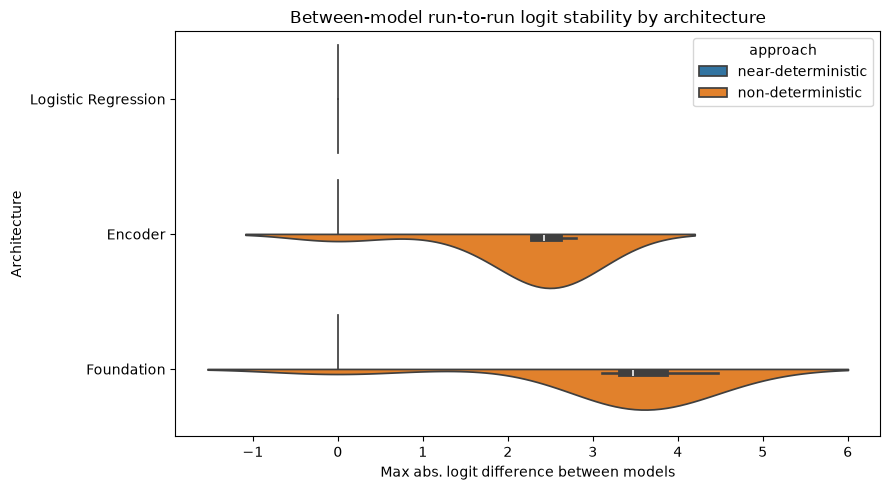

In [38]:
# create plot
plt.figure(figsize = (9, 5))

# violin plot
sns.violinplot(data = df_plot, 
               y = "architecture", 
               x = "max_diff", 
               hue = "approach", 
               split = True)

# set metadata
plt.xscale("linear")
plt.xlabel("Max abs. logit difference between models")
plt.ylabel("Architecture")
plt.title("Between-model run-to-run logit stability by architecture")
plt.tight_layout()

# save plot to storage
plt.savefig(Path(cfg.output_path).parent / "violin_within_model_stability.svg")

# print plot
plt.show()

In [39]:
# get tensors for architectures
architectures_config = [
    ("Logistic Regression",
     Path(cfg.output_directory_logistic_deterministic) / "logit_tensor_deterministic.npy",
     Path(cfg.output_directory_logistic_nondeterministic) / "logit_tensor_nondeterministic.npy"),
    ("Encoder",
     Path(cfg.output_directory_encoder_deterministic) / "logit_tensor_deterministic.npy",
     Path(cfg.output_directory_encoder_nondeterministic) / "logit_tensor_nondeterministic.npy"),
    ("Foundation",
     Path(cfg.output_directory_foundation_deterministic) / "logit_tensor_deterministic.npy",
     Path(cfg.output_directory_foundation_nondeterministic) / "logit_tensor_nondeterministic.npy"),
]

all_results = []

for arch_name, det_path, nondet_path in architectures_config:

    # use get_results function from above
    df = get_results(cfg, 
                     det_path, 
                     nondet_path, 
                     n_classes = 3)
    
    df["architecture"] = arch_name
    all_results.append(df)

# build disagreement_df
disagreement_df = pd.concat(all_results, ignore_index = True)
disagreement_df["pct_disagreement"] = 100 * disagreement_df["n_disagreements"] / 2376  #sample count

# save to storage
disagreement_df.to_csv(Path(cfg.output_path).parent / "class_level_disagreement.csv", 
                       encoding = "UTF-8",
                       index = False)

# verify
print(disagreement_df)

        bowker_stat  df          p_value     cohens_kappa  nondet_model  \
0  0.0000000000e+00   0              NaN 1.0000000000e+00             0   
1  0.0000000000e+00   0              NaN 1.0000000000e+00             1   
2  0.0000000000e+00   0              NaN 1.0000000000e+00             2   
3  0.0000000000e+00   0              NaN 1.0000000000e+00             3   
4  0.0000000000e+00   0              NaN 1.0000000000e+00             4   
5  0.0000000000e+00   0              NaN 1.0000000000e+00             5   
6  0.0000000000e+00   0              NaN 1.0000000000e+00             6   
7  0.0000000000e+00   0              NaN 1.0000000000e+00             7   
8  0.0000000000e+00   0              NaN 1.0000000000e+00             8   
9  0.0000000000e+00   0              NaN 1.0000000000e+00             9   
10 4.4415844008e+01   3 1.2313975546e-09 7.1263839332e-01             0   
11 9.2722488038e+01   3 5.6978424763e-20 7.0840890354e-01             1   
12 1.9072857143e+02   3 4

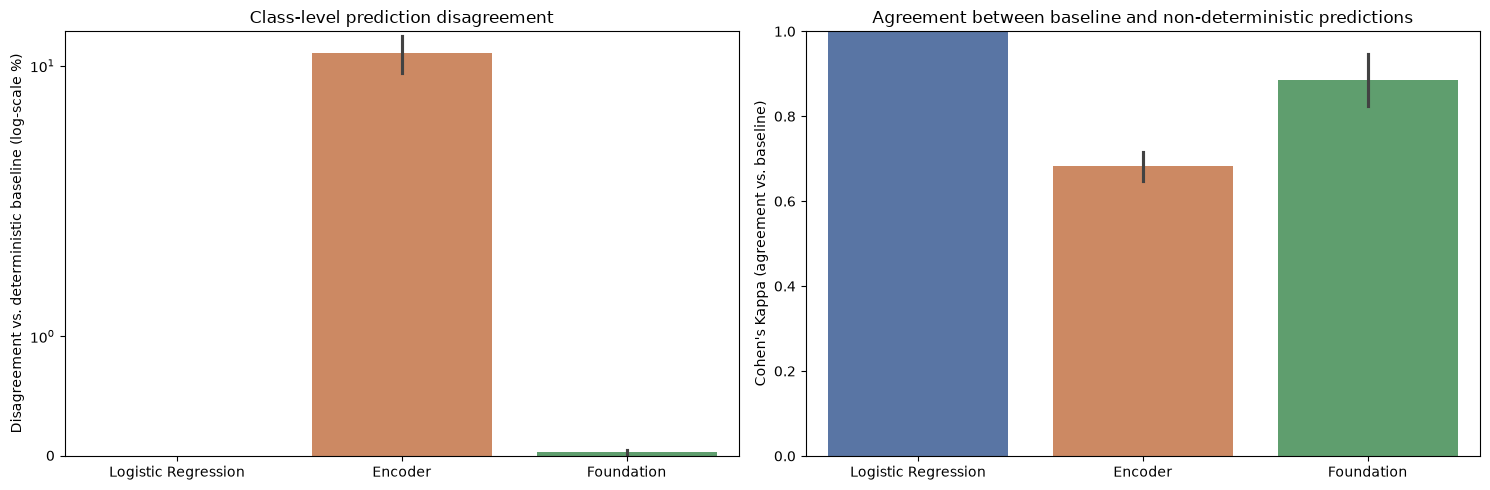

In [40]:
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# disagreement on class-level predictions
sns.barplot(
    data = disagreement_df, 
    x = "architecture", 
    y = "pct_disagreement",
    hue = "architecture", 
    palette = "deep", 
    errorbar = "sd", # use standard deviation for error bar
    ax = axes[0], 
    legend = False
)

axes[0].set_ylabel("Disagreement vs. deterministic baseline (log-scale %)")
axes[0].set_yscale("symlog")
axes[0].set_xlabel("")
axes[0].set_title("Class-level prediction disagreement")

# disagreement between baseline and non-deterministic
sns.barplot(
    data = disagreement_df, 
    x = "architecture", 
    y = "cohens_kappa",
    hue = "architecture", 
    palette = "deep", 
    errorbar = "sd", # use standard deviation for error bar
    ax = axes[1], 
    legend = False
)

# set metadata
axes[1].set_ylabel("Cohen's Kappa (agreement vs. baseline)")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1)
axes[1].set_title("Agreement between baseline and non-deterministic predictions")

plt.tight_layout()

# save to storage
plt.savefig(Path(cfg.output_path).parent / "class_level_disagreement_bars.svg")

# print plot
plt.show()

In [41]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [42]:
# select first run encoder near-det
encoder_deterministic_tensor = np.load(Path(cfg.output_directory_encoder_deterministic) / "logit_tensor_deterministic.npy")
encoder_nondeterministic_tensor = np.load(Path(cfg.output_directory_encoder_nondeterministic) / "logit_tensor_nondeterministic.npy")

In [43]:
# convert logits to classes with argmax
encoder_deterministic_classes = np.argmax(encoder_deterministic_tensor[0, 0], axis = -1)
encoder_nondeterministic_classes = np.argmax(encoder_nondeterministic_tensor[0, 0], axis = -1)

In [44]:
# create confusion matrix
cm = confusion_matrix(
    encoder_deterministic_classes,
    encoder_nondeterministic_classes
)

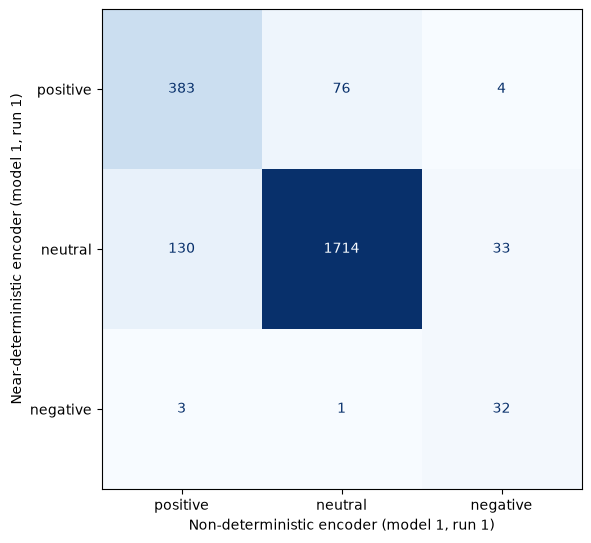

In [45]:
# create plot
fig, ax = plt.subplots(figsize = (6, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ["positive", "neutral", "negative"]
)

display.plot(ax = ax, 
             cmap = "Blues", 
             values_format = "d", 
             colorbar = False)

ax.set_xlabel("Non-deterministic encoder (model 1, run 1)")
ax.set_ylabel("Near-deterministic encoder (model 1, run 1)")

plt.tight_layout()

# save plot to storage
plt.savefig(Path(cfg.output_path).parent / "disagreement_matrix_encoder.svg")

plt.show()